# Spotify Top Songs EDA

Comprehensive exploratory data analysis of `spotify_top_songs_audio_features.csv` to understand streaming patterns, artist performance, and audio feature relationships.


In [29]:
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.3f}'.format)

# Load data
DATA_PATH = 'spotify_top_songs_audio_features.csv'
df = pd.read_csv(DATA_PATH)
print(f"✓ Dataset loaded: {df.shape[0]:,} songs with {df.shape[1]} features")


✓ Dataset loaded: 6,513 songs with 19 features


## Dataset Overview

In [30]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMissing Values:\n{df.isna().sum()}")


DATASET OVERVIEW
Shape: 6,513 rows × 19 columns

Data Types:
id                   object
artist_names         object
track_name           object
source               object
key                  object
mode                 object
time_signature       object
danceability        float64
energy              float64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
loudness            float64
tempo               float64
duration_ms           int64
weeks_on_chart        int64
streams               int64
dtype: object

Missing Values:
id                  0
artist_names        0
track_name          0
source              0
key                 0
mode                0
time_signature      0
danceability        0
energy              0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
loudness            0
tempo               0
duration_ms         0
we

In [31]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\n" + "=" * 60)
print("NUMERIC FEATURES SUMMARY")
print("=" * 60)
df[numeric_cols].describe().T



NUMERIC FEATURES SUMMARY


,count,mean,std,min,25%,50%,75%,max
danceability,"6,513.000",0.682,0.142,0.150,0.591,0.698,0.785,0.985
energy,"6,513.000",0.637,0.165,0.022,0.534,0.651,0.759,0.989
speechiness,"6,513.000",0.122,0.113,0.023,0.044,0.072,0.163,0.966
acousticness,"6,513.000",0.237,0.245,0.000,0.044,0.145,0.356,0.994
instrumentalness,"6,513.000",0.012,0.075,0.000,0.000,0.000,0.000,0.953
liveness,"6,513.000",0.180,0.138,0.020,0.097,0.124,0.219,0.977
valence,"6,513.000",0.492,0.227,0.032,0.316,0.489,0.669,0.982
loudness,"6,513.000",-6.351,2.536,-34.475,-7.564,-5.983,-4.673,1.509
tempo,"6,513.000",122.117,29.416,46.718,98.007,120.034,142.025,212.117
duration_ms,"6,513.000","202,566.684","49,199.592","30,133.000","173,038.000","198,367.000","226,003.000","690,732.000"


## Stream Performance & Popularity Metrics



STREAMS & POPULARITY ANALYSIS
Total Streams: 709,687,227,805
Average Streams per Song: 108,964,721
Median Streams: 27,128,557
Stream Range: 2,525,159 - 3,528,450,184
Streams Skewness: 5.28
Streams Kurtosis: 43.48


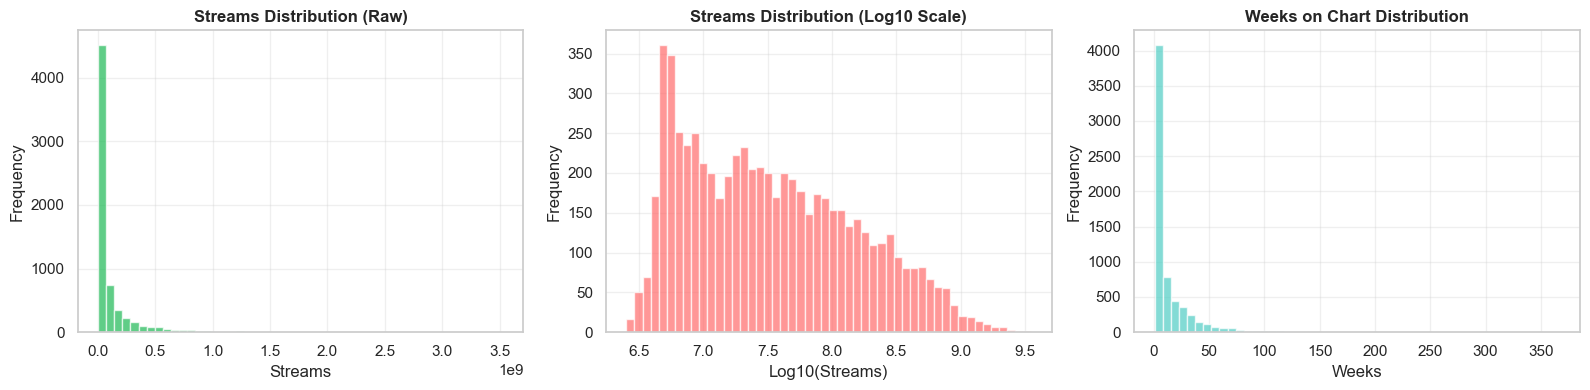

In [32]:
print("\n" + "=" * 60)
print("STREAMS & POPULARITY ANALYSIS")
print("=" * 60)

streams_stats = df['streams'].describe()
print(f"Total Streams: {df['streams'].sum():,.0f}")
print(f"Average Streams per Song: {df['streams'].mean():,.0f}")
print(f"Median Streams: {df['streams'].median():,.0f}")
print(f"Stream Range: {df['streams'].min():,.0f} - {df['streams'].max():,.0f}")
print(f"Streams Skewness: {df['streams'].skew():.2f}")
print(f"Streams Kurtosis: {df['streams'].kurtosis():.2f}")

# Create streams distribution visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Original distribution
axes[0].hist(df['streams'], bins=50, color='#1DB954', edgecolor='white', alpha=0.7)
axes[0].set_title('Streams Distribution (Raw)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Streams')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# Log scale distribution
axes[1].hist(np.log10(df['streams']), bins=50, color='#FF6B6B', edgecolor='white', alpha=0.7)
axes[1].set_title('Streams Distribution (Log10 Scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log10(Streams)')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

# Weeks on chart
axes[2].hist(df['weeks_on_chart'], bins=50, color='#4ECDC4', edgecolor='white', alpha=0.7)
axes[2].set_title('Weeks on Chart Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Weeks')
axes[2].set_ylabel('Frequency')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [33]:
print("\n" + "=" * 60)
print("TOP 10 TRACKS")
print("=" * 60)
top_tracks = df[['track_name', 'artist_names', 'streams', 'weeks_on_chart']].sort_values('streams', ascending=False).head(10)
for idx, row in top_tracks.iterrows():
    print(f"{row['track_name'][:50]:50} | {row['streams']:>12,.0f} streams | {int(row['weeks_on_chart']):3d} weeks")



TOP 10 TRACKS
Blinding Lights                                    | 3,528,450,184 streams | 224 weeks
Shape of You                                       | 3,509,169,565 streams | 333 weeks
Someone You Loved                                  | 3,029,241,037 streams | 270 weeks
Perfect                                            | 2,797,600,939 streams | 363 weeks
As It Was                                          | 2,580,052,047 streams | 102 weeks
lovely (with Khalid)                               | 2,417,312,282 streams | 308 weeks
Watermelon Sugar                                   | 2,351,753,978 streams | 205 weeks
Heat Waves                                         | 2,265,473,708 streams | 120 weeks
Dance Monkey                                       | 2,250,351,787 streams | 104 weeks
STAY (with Justin Bieber)                          | 2,168,948,336 streams |  80 weeks


## Top Songs and Artists

In [34]:
top_tracks = df[['track_name', 'artist_names', 'streams', 'weeks_on_chart']].sort_values('streams', ascending=False).head(10)
top_tracks

,track_name,artist_names,streams,weeks_on_chart
435,Blinding Lights,The Weeknd,3528450184,224
6383,Shape of You,Ed Sheeran,3509169565,333
6378,Someone You Loved,Lewis Capaldi,3029241037,270
748,Perfect,Ed Sheeran,2797600939,363
3523,As It Was,Harry Styles,2580052047,102
752,lovely (with Khalid),"Billie Eilish, Khalid",2417312282,308
5391,Watermelon Sugar,Harry Styles,2351753978,205
33,Heat Waves,Glass Animals,2265473708,120
1530,Dance Monkey,Tones And I,2250351787,104
4550,STAY (with Justin Bieber),"The Kid LAROI, Justin Bieber",2168948336,80



TOP 15 ARTISTS
   artist_names  total_streams  avg_streams  songs  avg_weeks
   Taylor Swift    15388585740     87934775    175      7.800
     Ed Sheeran    13111071610    291357146     45     37.500
     The Weeknd    11184004532    223680090     50     20.800
      Bad Bunny    10532229467    150460420     70     12.900
   Harry Styles     9661158399    241528959     40     20.000
  Billie Eilish     9633076229    181756155     53     21.000
 Olivia Rodrigo     8885676876    296189229     30     23.000
  Ariana Grande     8364532797    139408879     60     12.800
          Drake     7604179081     68506117    111      7.800
    Post Malone     7362247507    131468705     56     16.200
       Dua Lipa     6977155599    303354591     23     31.000
Imagine Dragons     6787623268    183449277     37     40.800
   XXXTENTACION     6624066687    157715873     42     23.700
   Travis Scott     5814429994    200497586     29     25.900
       Doja Cat     5553782349    308543463     18    

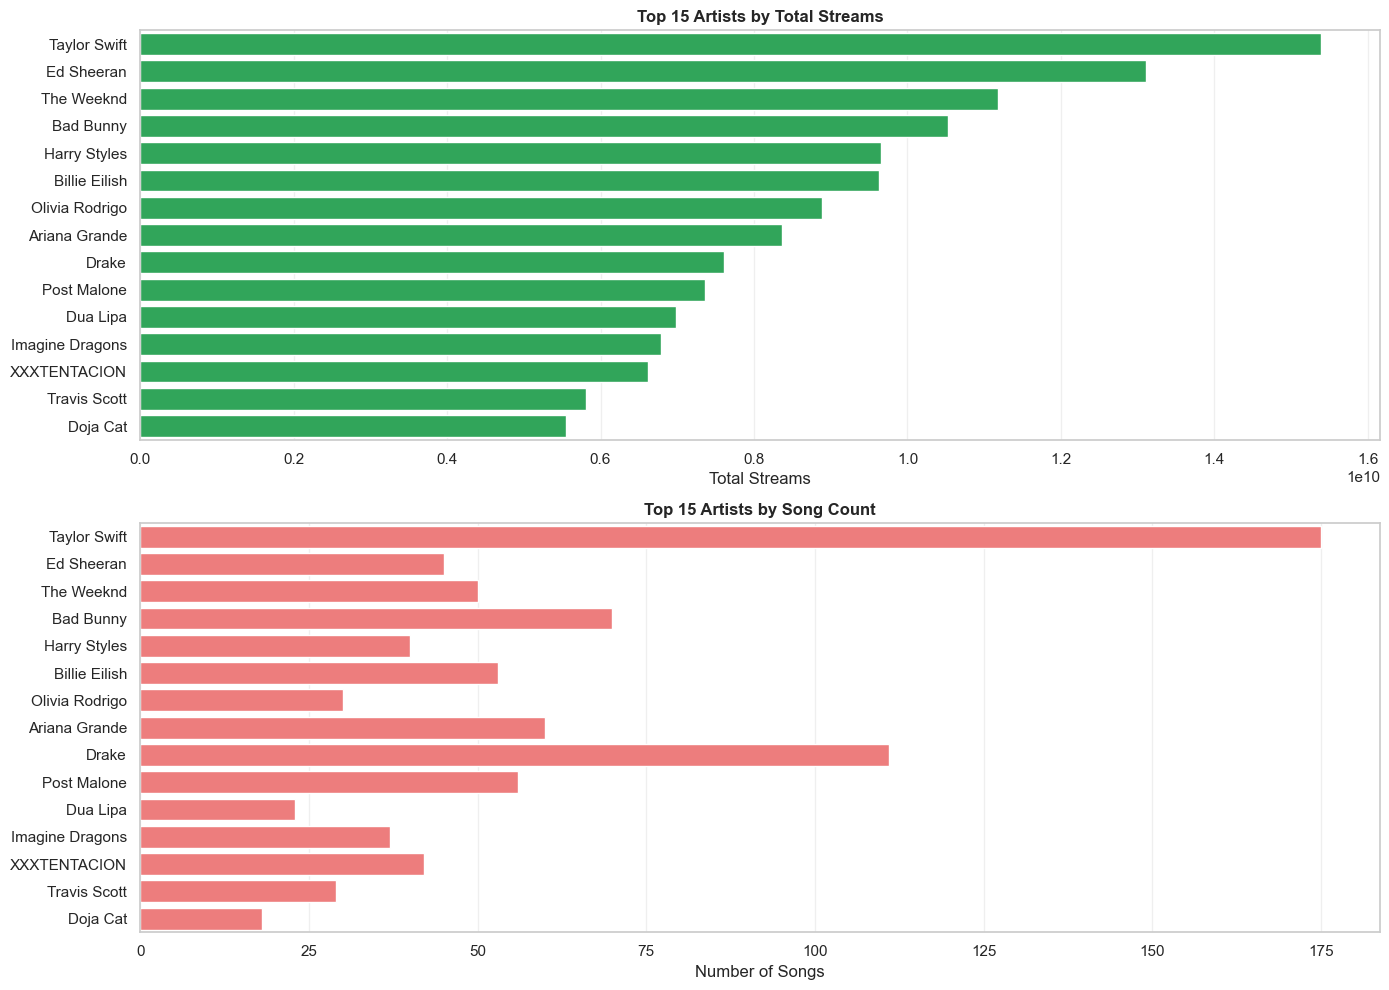

In [35]:
print("\n" + "=" * 60)
print("TOP 15 ARTISTS")
print("=" * 60)
top_artists = (
    df.groupby('artist_names', as_index=False)
      .agg(
          total_streams=('streams', 'sum'), 
          avg_streams=('streams', 'mean'), 
          songs=('track_name', 'count'),
          avg_weeks=('weeks_on_chart', 'mean')
      )
      .sort_values('total_streams', ascending=False)
      .head(15)
)
top_artists['total_streams'] = top_artists['total_streams'].astype(int)
top_artists['avg_streams'] = top_artists['avg_streams'].astype(int)
top_artists['avg_weeks'] = top_artists['avg_weeks'].round(1)
print(top_artists.to_string(index=False))

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Total streams
sns.barplot(data=top_artists, x='total_streams', y='artist_names', color='#1DB954', ax=axes[0])
axes[0].set_title('Top 15 Artists by Total Streams', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Streams')
axes[0].set_ylabel('')
axes[0].grid(alpha=0.3, axis='x')

# Number of songs
sns.barplot(data=top_artists, x='songs', y='artist_names', color='#FF6B6B', ax=axes[1])
axes[1].set_title('Top 15 Artists by Song Count', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Songs')
axes[1].set_ylabel('')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


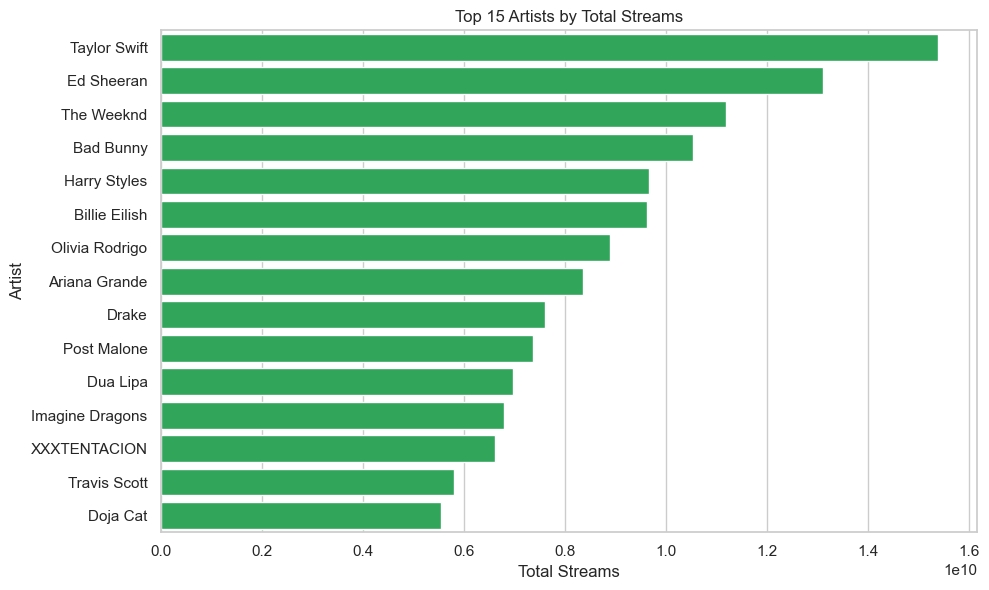

In [36]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_artists, x='total_streams', y='artist_names', color='#1DB954')
plt.title('Top 15 Artists by Total Streams')
plt.xlabel('Total Streams')
plt.ylabel('Artist')
plt.tight_layout()
plt.show()

## Audio Features Analysis



AUDIO FEATURES OVERVIEW
                    mean    std     min     max
danceability       0.682  0.142   0.150   0.985
energy             0.637  0.165   0.022   0.989
speechiness        0.122  0.113   0.023   0.966
acousticness       0.237  0.245   0.000   0.994
instrumentalness   0.012  0.075   0.000   0.953
liveness           0.180  0.138   0.020   0.977
valence            0.492  0.227   0.032   0.982
loudness          -6.351  2.536 -34.475   1.509
tempo            122.117 29.416  46.718 212.117
                    mean    std     min     max
danceability       0.682  0.142   0.150   0.985
energy             0.637  0.165   0.022   0.989
speechiness        0.122  0.113   0.023   0.966
acousticness       0.237  0.245   0.000   0.994
instrumentalness   0.012  0.075   0.000   0.953
liveness           0.180  0.138   0.020   0.977
valence            0.492  0.227   0.032   0.982
loudness          -6.351  2.536 -34.475   1.509
tempo            122.117 29.416  46.718 212.117


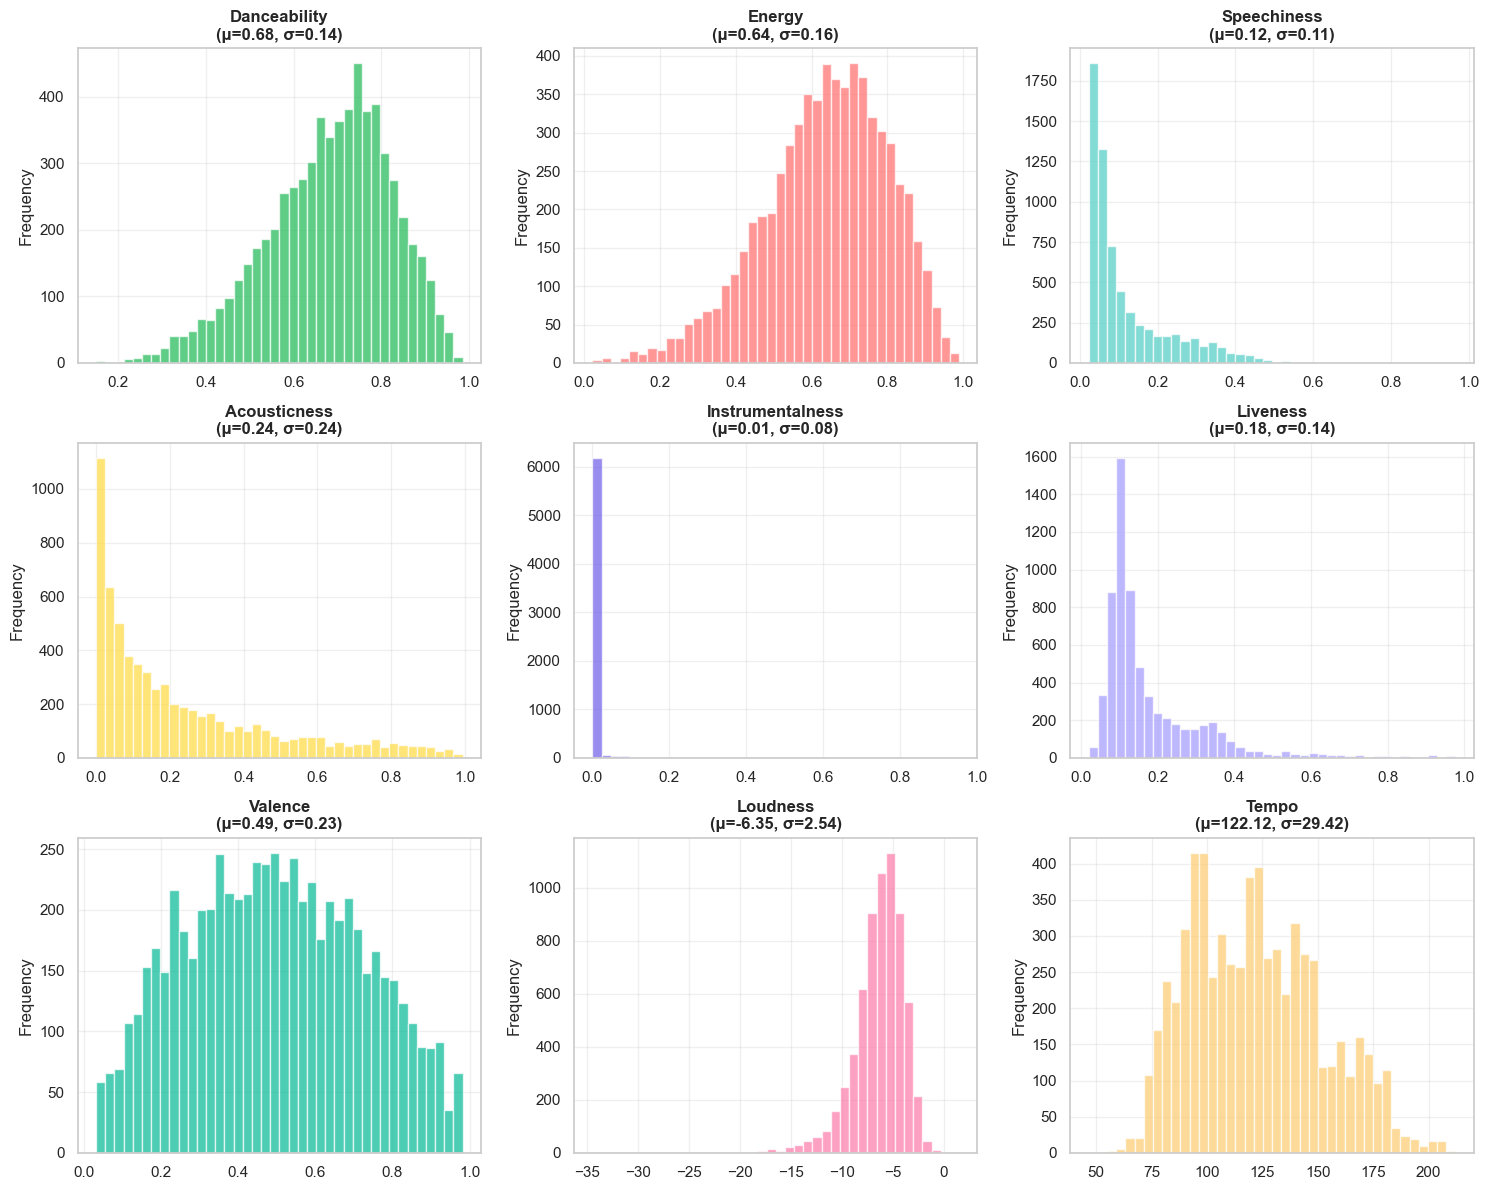

In [37]:
print("\n" + "=" * 60)
print("AUDIO FEATURES OVERVIEW")
print("=" * 60)

audio_features = [
    'danceability', 'energy', 'speechiness', 'acousticness',
    'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo'
]

audio_stats = df[audio_features].describe().T
print(audio_stats[['mean', 'std', 'min', 'max']])

# Visualize distributions
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

colors = ['#1DB954', '#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7', '#A29BFE', '#00B894', '#FD79A8', '#FDCB6E']

for ax, col, color in zip(axes, audio_features, colors):
    ax.hist(df[col].dropna(), bins=40, color=color, edgecolor='white', alpha=0.7)
    ax.set_title(f'{col.capitalize()}\n(μ={df[col].mean():.2f}, σ={df[col].std():.2f})', fontweight='bold')
    ax.set_ylabel('Frequency')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()



FEATURE CORRELATIONS WITH STREAMS

Correlation with Streams (sorted by absolute value):
weeks_on_chart       :   0.856
speechiness          :  -0.086
liveness             :  -0.039
valence              :   0.037
loudness             :   0.036
instrumentalness     :  -0.019
duration_ms          :   0.015
acousticness         :   0.013
tempo                :  -0.012
danceability         :   0.012
energy               :   0.001


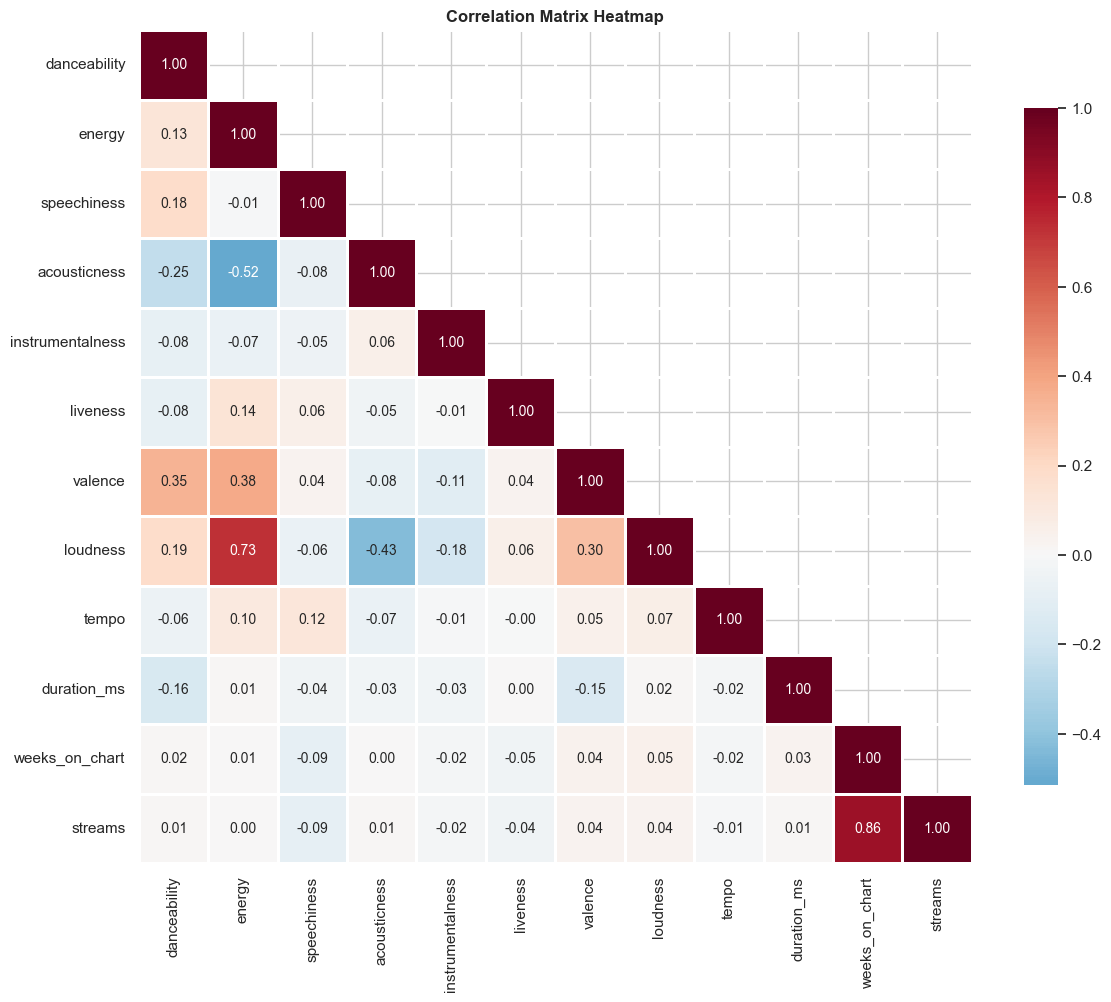

In [38]:
print("\n" + "=" * 60)
print("FEATURE CORRELATIONS WITH STREAMS")
print("=" * 60)

corr_matrix = df[numeric_cols].corr()
corr_with_streams = corr_matrix['streams'].drop('streams').sort_values(key=lambda x: x.abs(), ascending=False)

print("\nCorrelation with Streams (sorted by absolute value):")
for feature, corr in corr_with_streams.items():
    print(f"{feature:20} : {corr:7.3f}")

# Correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax, mask=mask)
ax.set_title('Correlation Matrix Heatmap', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## Key Feature Relationships with Streams


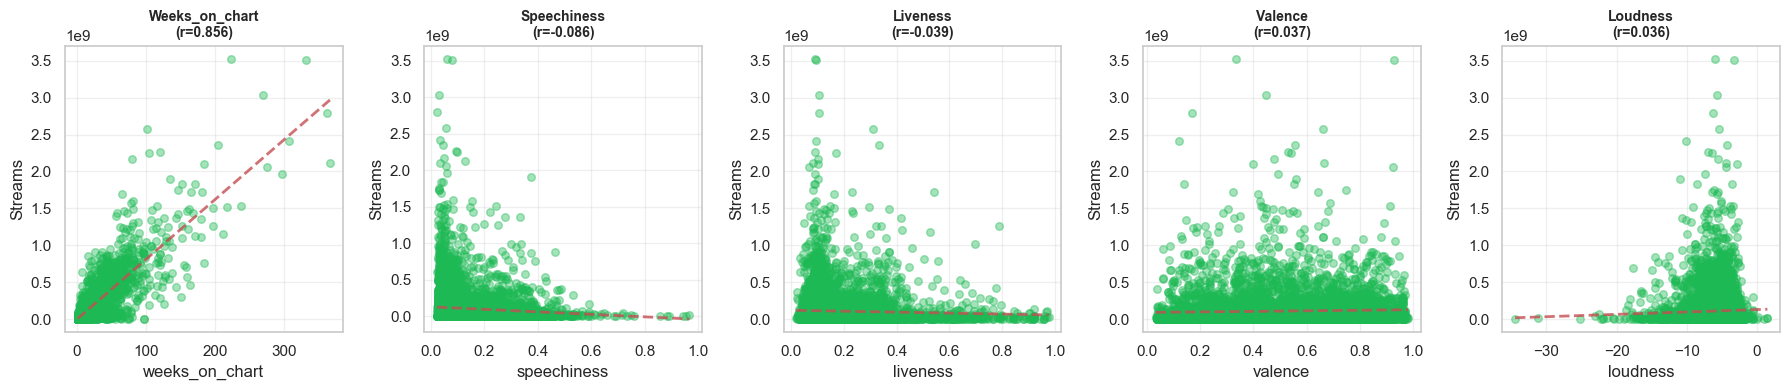

In [39]:
# Top correlates with streams
top_correlates = corr_with_streams.head(5)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for idx, (feature, corr) in enumerate(top_correlates.items()):
    axes[idx].scatter(df[feature], df['streams'], alpha=0.4, color='#1DB954', s=30)
    axes[idx].set_title(f'{feature.capitalize()}\n(r={corr:.3f})', fontweight='bold', fontsize=10)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Streams')
    axes[idx].grid(alpha=0.3)
    
    # Add trend line
    z = np.polyfit(df[feature].dropna(), df['streams'][df[feature].notna()], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feature].min(), df[feature].max(), 100)
    axes[idx].plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.show()



CATEGORICAL FEATURES ANALYSIS

Mode Distribution:
mode
Major    3747
Minor    2766
Name: count, dtype: int64

Mode Streams Statistics:
       count            mean         median           sum
mode                                                     
Major   3747 109,618,620.556 27,305,333.000  410740971224
Minor   2766 108,078,906.935 27,062,977.500  298946256581

Key Distribution (Top 10):
key
C#/Db    942
C        705
G        595
B        567
G#/Ab    553
F        531
A        524
D        524
F#/Gb    501
A#/Bb    465
Name: count, dtype: int64

Time Signature Distribution:
time_signature
1            25
3 beats     324
4 beats    6057
5 beats     107
Name: count, dtype: int64


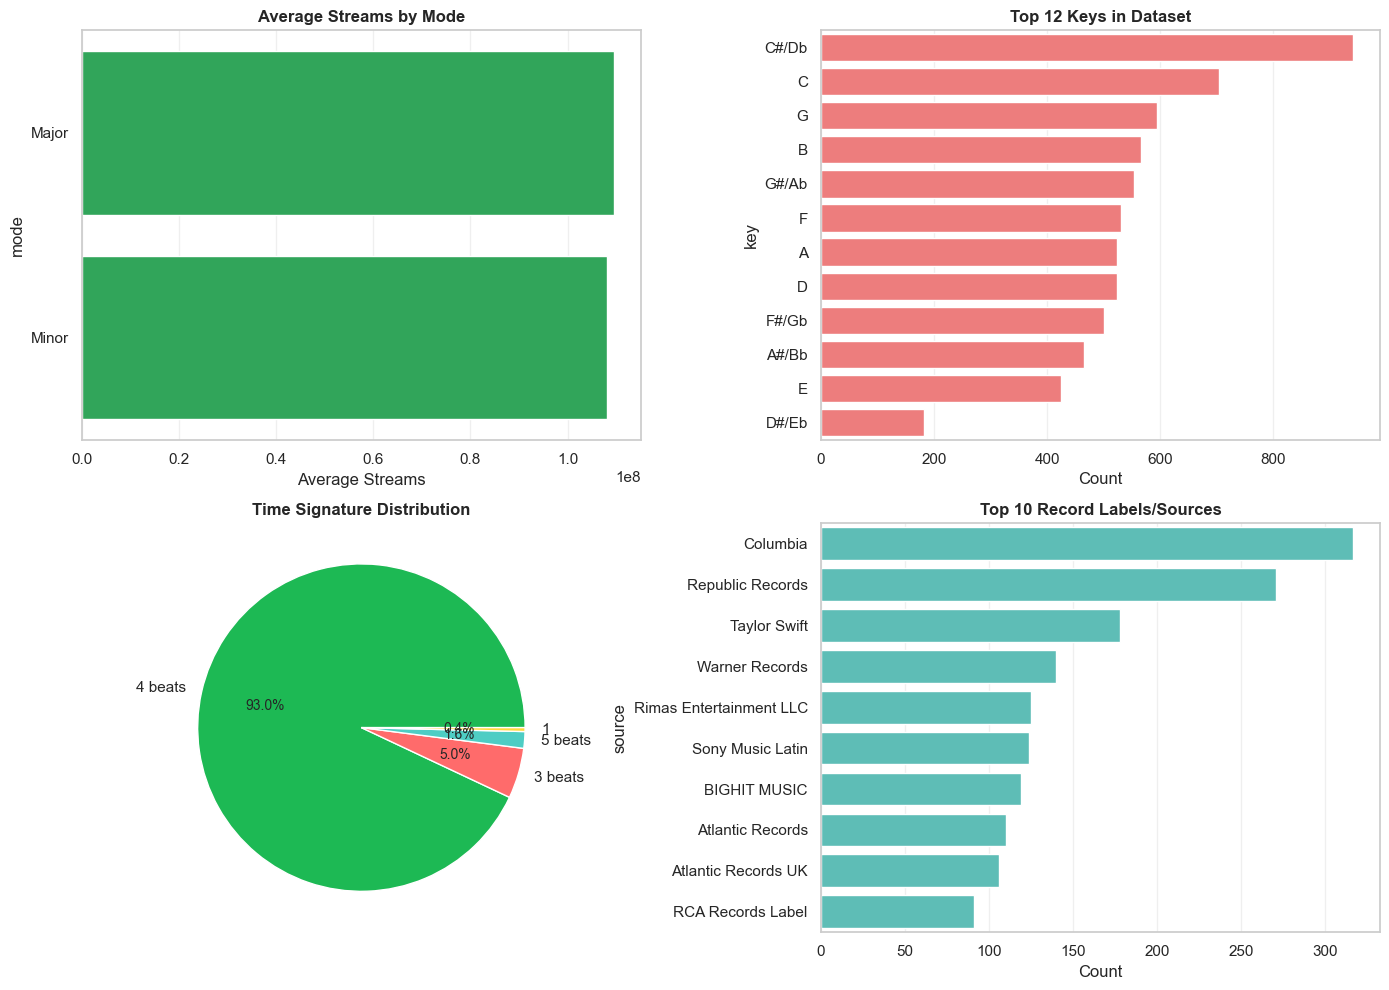

In [40]:
print("\n" + "=" * 60)
print("CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

# Mode analysis
print(f"\nMode Distribution:")
print(df['mode'].value_counts())
mode_streams = df.groupby('mode')['streams'].agg(['count', 'mean', 'median', 'sum'])
print(f"\nMode Streams Statistics:")
print(mode_streams)

# Key analysis
print(f"\nKey Distribution (Top 10):")
print(df['key'].value_counts().head(10))

# Time signature analysis
print(f"\nTime Signature Distribution:")
print(df['time_signature'].value_counts().sort_index())

# Create categorical visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mode
mode_data = df.groupby('mode')['streams'].mean().sort_values(ascending=False)
sns.barplot(x=mode_data.values, y=mode_data.index, color='#1DB954', ax=axes[0, 0])
axes[0, 0].set_title('Average Streams by Mode', fontweight='bold')
axes[0, 0].set_xlabel('Average Streams')
axes[0, 0].grid(alpha=0.3, axis='x')

# Key (top 12)
key_counts = df['key'].value_counts().head(12)
sns.barplot(y=key_counts.index, x=key_counts.values, color='#FF6B6B', ax=axes[0, 1])
axes[0, 1].set_title('Top 12 Keys in Dataset', fontweight='bold')
axes[0, 1].set_xlabel('Count')
axes[0, 1].grid(alpha=0.3, axis='x')

# Time Signature
time_sig_counts = df['time_signature'].value_counts()
axes[1, 0].pie(time_sig_counts.values, labels=time_sig_counts.index, autopct='%1.1f%%', 
               colors=['#1DB954', '#FF6B6B', '#4ECDC4', '#FFD93D', '#6C5CE7'][:len(time_sig_counts)])
axes[1, 0].set_title('Time Signature Distribution', fontweight='bold')

# Source (top 10)
source_counts = df['source'].value_counts().head(10)
sns.barplot(y=source_counts.index, x=source_counts.values, color='#4ECDC4', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Record Labels/Sources', fontweight='bold')
axes[1, 1].set_xlabel('Count')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


## Relationships With Streams


ADVANCED PATTERN ANALYSIS

Duration Statistics (ms):
  Mean: 202.6 seconds (3.38 minutes)
  Median: 198.4 seconds
  Min: 30.1 seconds
  Max: 690.7 seconds

Streams by Song Duration:
              count            mean         median
duration_bin                                      
<2m             151  62,764,110.728 15,912,093.000
2-3m           1913  99,732,724.244 23,352,800.000
3-4m           3376 117,407,818.781 31,549,371.500
4-5m            850 113,797,810.438 23,827,390.000
>5m             219  72,515,108.256 18,679,089.000


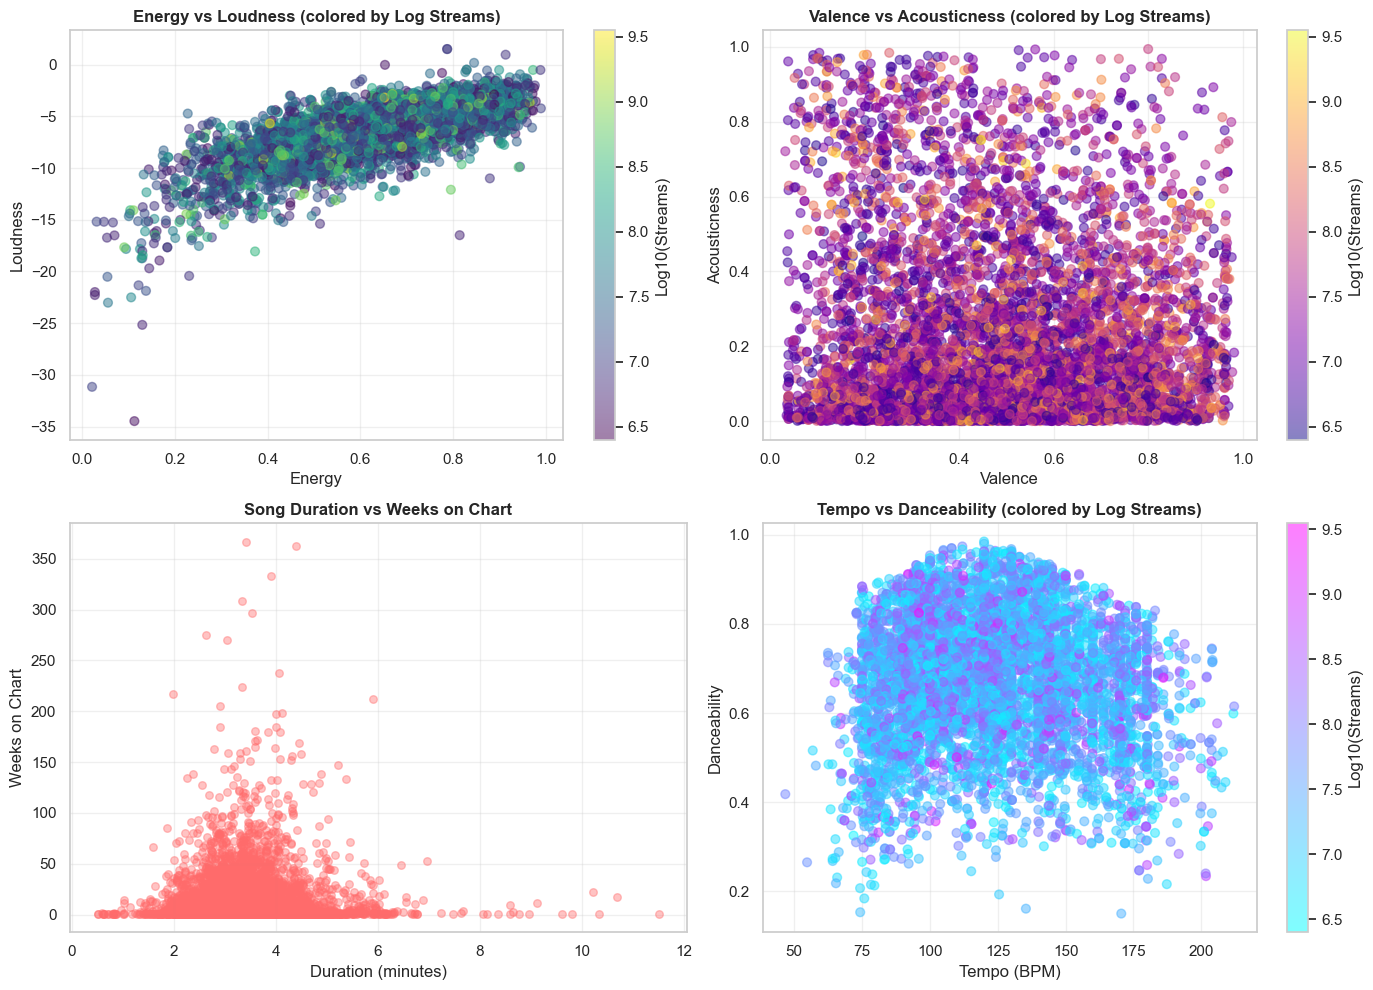

In [41]:
print("\n" + "=" * 60)
print("ADVANCED PATTERN ANALYSIS")
print("=" * 60)

# Duration analysis
print(f"\nDuration Statistics (ms):")
duration_stats = df['duration_ms'].describe()
print(f"  Mean: {duration_stats['mean']/1000:.1f} seconds ({duration_stats['mean']/60000:.2f} minutes)")
print(f"  Median: {duration_stats['50%']/1000:.1f} seconds")
print(f"  Min: {duration_stats['min']/1000:.1f} seconds")
print(f"  Max: {duration_stats['max']/1000:.1f} seconds")

# Create duration bins and analyze streams
df['duration_bin'] = pd.cut(df['duration_ms']/1000, bins=[0, 120, 180, 240, 300, 600], 
                             labels=['<2m', '2-3m', '3-4m', '4-5m', '>5m'])
duration_analysis = df.groupby('duration_bin', observed=True)['streams'].agg(['count', 'mean', 'median'])
print(f"\nStreams by Song Duration:")
print(duration_analysis)

# Multi-feature relationships
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Energy vs Loudness (colored by Streams)
scatter1 = axes[0, 0].scatter(df['energy'], df['loudness'], c=np.log10(df['streams']), 
                               cmap='viridis', alpha=0.5, s=40)
axes[0, 0].set_title('Energy vs Loudness (colored by Log Streams)', fontweight='bold')
axes[0, 0].set_xlabel('Energy')
axes[0, 0].set_ylabel('Loudness')
plt.colorbar(scatter1, ax=axes[0, 0], label='Log10(Streams)')
axes[0, 0].grid(alpha=0.3)

# Valence vs Acousticness
scatter2 = axes[0, 1].scatter(df['valence'], df['acousticness'], c=np.log10(df['streams']), 
                               cmap='plasma', alpha=0.5, s=40)
axes[0, 1].set_title('Valence vs Acousticness (colored by Log Streams)', fontweight='bold')
axes[0, 1].set_xlabel('Valence')
axes[0, 1].set_ylabel('Acousticness')
plt.colorbar(scatter2, ax=axes[0, 1], label='Log10(Streams)')
axes[0, 1].grid(alpha=0.3)

# Duration vs Weeks on Chart
axes[1, 0].scatter(df['duration_ms']/60000, df['weeks_on_chart'], alpha=0.4, color='#FF6B6B', s=30)
axes[1, 0].set_title('Song Duration vs Weeks on Chart', fontweight='bold')
axes[1, 0].set_xlabel('Duration (minutes)')
axes[1, 0].set_ylabel('Weeks on Chart')
axes[1, 0].grid(alpha=0.3)

# Tempo vs Danceability
scatter3 = axes[1, 1].scatter(df['tempo'], df['danceability'], c=np.log10(df['streams']), 
                               cmap='cool', alpha=0.5, s=40)
axes[1, 1].set_title('Tempo vs Danceability (colored by Log Streams)', fontweight='bold')
axes[1, 1].set_xlabel('Tempo (BPM)')
axes[1, 1].set_ylabel('Danceability')
plt.colorbar(scatter3, ax=axes[1, 1], label='Log10(Streams)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Label & Source Analysis



LABEL & SOURCE PERFORMANCE

Top 20 Labels/Sources:
                      source  songs  avg_streams  total_streams  avg_weeks
                    Columbia    317    151752836    48105649090     15.334
            Republic Records    271    145954451    39553656302     15.830
         Atlantic Records UK    106    214878850    22777158179     26.755
     Rimas Entertainment LLC    125    180491114    22561389273     15.320
            Atlantic Records    110    161012064    17711327042     20.545
              Warner Records    140    120433531    16860694380     14.050
            Sony Music Latin    124    133842216    16596434787     18.411
                Taylor Swift    178     72971092    12988854508      5.758
               UMLE - Latino     87    143893609    12518743992     19.506
 Darkroom/Interscope Records     50    211398389    10569919492     22.920
           RCA Records Label     91    106320972     9675208541     11.725
           Olivia Rodrigo PS     28    311564591

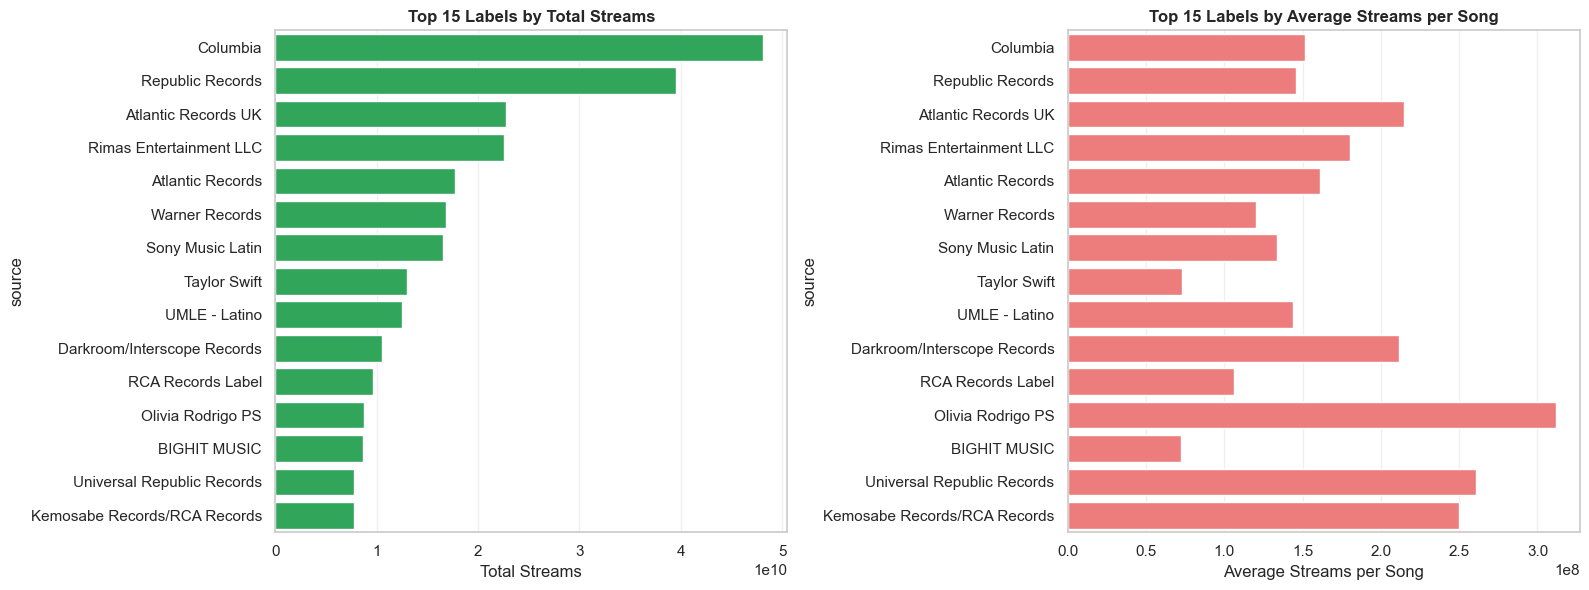

In [42]:
print("\n" + "=" * 60)
print("LABEL & SOURCE PERFORMANCE")
print("=" * 60)

source_summary = (
    df.groupby('source', as_index=False)
      .agg(
          songs=('track_name', 'count'),
          avg_streams=('streams', 'mean'),
          total_streams=('streams', 'sum'),
          avg_weeks=('weeks_on_chart', 'mean')
      )
      .sort_values('total_streams', ascending=False)
      .head(20)
)
source_summary['avg_streams'] = source_summary['avg_streams'].astype(int)
source_summary['total_streams'] = source_summary['total_streams'].astype(int)
print("\nTop 20 Labels/Sources:")
print(source_summary.to_string(index=False))

# Visualize top sources
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_sources = source_summary.head(15)

sns.barplot(data=top_sources, x='total_streams', y='source', color='#1DB954', ax=axes[0])
axes[0].set_title('Top 15 Labels by Total Streams', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Total Streams')
axes[0].grid(alpha=0.3, axis='x')

sns.barplot(data=top_sources, x='avg_streams', y='source', color='#FF6B6B', ax=axes[1])
axes[1].set_title('Top 15 Labels by Average Streams per Song', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Average Streams per Song')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



AUDIO FEATURE PROFILES BY STREAM SUCCESS

Average Audio Features by Stream Success:
                  danceability  energy  speechiness  acousticness  \
streams_category                                                    
Low                      0.682   0.637        0.122         0.237   
Medium                   0.651   0.649        0.092         0.225   
High                     0.552   0.544        0.047         0.462   

                  instrumentalness  liveness  valence  loudness   tempo  
streams_category                                                         
Low                          0.013     0.180    0.493    -6.354 122.148  
Medium                       0.007     0.179    0.475    -6.020 117.724  
High                         0.000     0.133    0.444    -6.092 126.856  


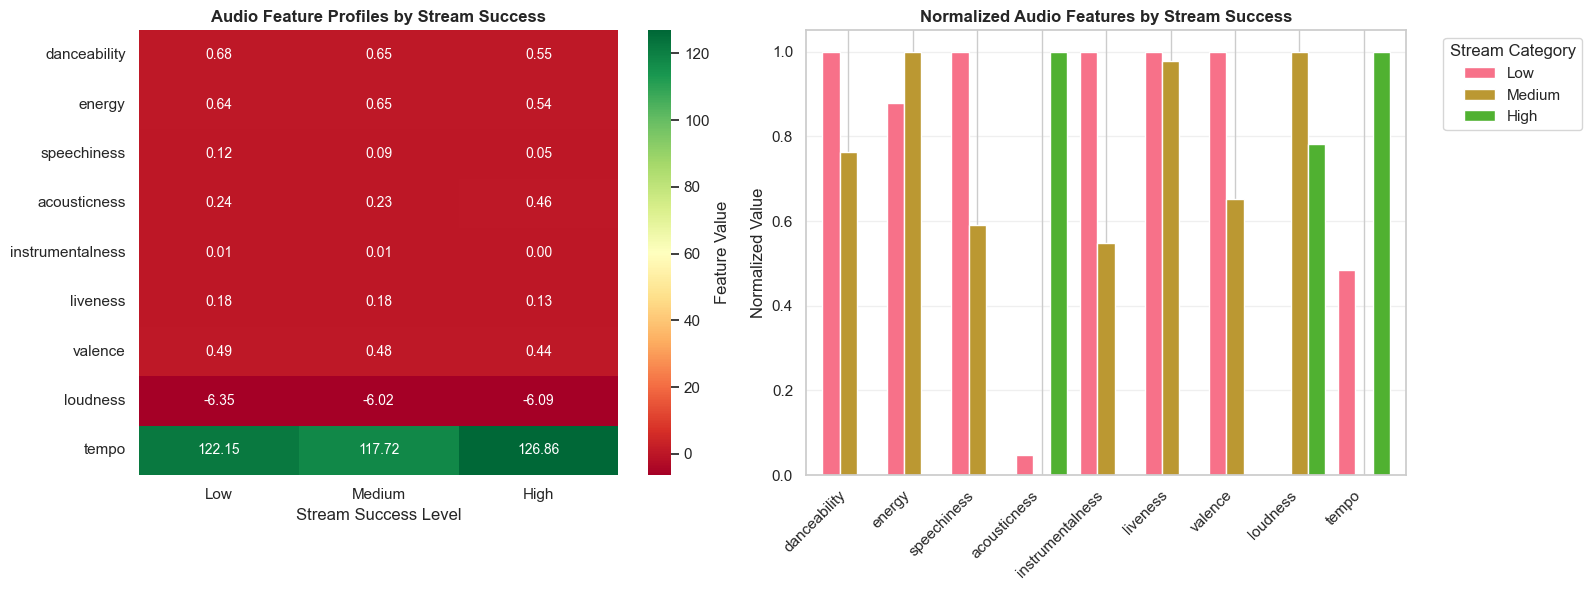

In [43]:
# Create audio feature profiles for successful vs less successful songs
df['streams_category'] = pd.cut(df['streams'], bins=3, labels=['Low', 'Medium', 'High'])

print("\n" + "=" * 60)
print("AUDIO FEATURE PROFILES BY STREAM SUCCESS")
print("=" * 60)

feature_profile = df.groupby('streams_category')[audio_features].mean()
print("\nAverage Audio Features by Stream Success:")
print(feature_profile.round(3))

# Visualize feature profiles
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap of feature profiles
sns.heatmap(feature_profile.T, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[0], 
            cbar_kws={'label': 'Feature Value'})
axes[0].set_title('Audio Feature Profiles by Stream Success', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Stream Success Level')

# Feature comparison (normalized)
feature_profile_norm = (feature_profile - feature_profile.min()) / (feature_profile.max() - feature_profile.min())
feature_profile_norm.T.plot(kind='bar', ax=axes[1], width=0.8)
axes[1].set_title('Normalized Audio Features by Stream Success', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Normalized Value')
axes[1].legend(title='Stream Category', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1].grid(alpha=0.3, axis='y')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Key Insights & Takeaways


In [44]:
print("\n" + "=" * 60)
print("EXECUTIVE SUMMARY - KEY FINDINGS")
print("=" * 60)

print(f"""
📊 DATASET SCALE:
   • {len(df):,} songs analyzed across {df.shape[1]} features
   • Total streams: {df['streams'].sum()/1e9:.2f}B (billion)
   • Streams range: {df['streams'].min():,.0f} to {df['streams'].max():,.0f}

🎵 PERFORMANCE METRICS:
   • Average streams per song: {df['streams'].mean():,.0f}
   • Median streams: {df['streams'].median():,.0f}
   • Streams heavily right-skewed (skewness: {df['streams'].skew():.2f})
   • Top track: "{top_tracks.iloc[0]['track_name']}" ({top_tracks.iloc[0]['streams']:,.0f} streams)
   • Top artist: {top_artists.iloc[0]['artist_names']} ({top_artists.iloc[0]['total_streams']:,.0f} total streams)

🔗 STRONGEST CORRELATES WITH STREAMS:
   1. {corr_with_streams.index[0]:20} (r = {corr_with_streams.iloc[0]:+.3f})
   2. {corr_with_streams.index[1]:20} (r = {corr_with_streams.iloc[1]:+.3f})
   3. {corr_with_streams.index[2]:20} (r = {corr_with_streams.iloc[2]:+.3f})
   4. {corr_with_streams.index[3]:20} (r = {corr_with_streams.iloc[3]:+.3f})
   5. {corr_with_streams.index[4]:20} (r = {corr_with_streams.iloc[4]:+.3f})

🎼 AUDIO CHARACTERISTICS:
   • Most songs are in Major mode ({(df['mode']=='Major').sum()}/{len(df)} = {(df['mode']=='Major').sum()/len(df)*100:.1f}%)
   • Most common key: {df['key'].value_counts().index[0]} ({df['key'].value_counts().iloc[0]} songs)
   • Dominant time signature: {df['time_signature'].value_counts().index[0]} ({df['time_signature'].value_counts().iloc[0]/len(df)*100:.1f}% of songs)
   • Average tempo: {df['tempo'].mean():.1f} BPM
   • Songs tend to be moderately energetic (avg energy: {df['energy'].mean():.2f}/1.0)

💾 PLATFORM DISTRIBUTION:
   • Top label: {source_summary.iloc[0]['source']}
   • Number of unique labels: {df['source'].nunique()}
   • Label concentration: Top 10 labels account for {source_summary.head(10)['songs'].sum()/len(df)*100:.1f}% of songs

⚠️ DATA QUALITY NOTES:
   • Missing values: {int(df.isna().sum().sum())} (minimal data quality issues)
   • Log transformation recommended for streams (heavily skewed data)
   • Weeks on chart may leak information - be careful with train/test splits
""")

print("=" * 60)



EXECUTIVE SUMMARY - KEY FINDINGS

📊 DATASET SCALE:
   • 6,513 songs analyzed across 21 features
   • Total streams: 709.69B (billion)
   • Streams range: 2,525,159 to 3,528,450,184

🎵 PERFORMANCE METRICS:
   • Average streams per song: 108,964,721
   • Median streams: 27,128,557
   • Streams heavily right-skewed (skewness: 5.28)
   • Top track: "Blinding Lights" (3,528,450,184 streams)
   • Top artist: Taylor Swift (15,388,585,740 total streams)

🔗 STRONGEST CORRELATES WITH STREAMS:
   1. weeks_on_chart       (r = +0.856)
   2. speechiness          (r = -0.086)
   3. liveness             (r = -0.039)
   4. valence              (r = +0.037)
   5. loudness             (r = +0.036)

🎼 AUDIO CHARACTERISTICS:
   • Most songs are in Major mode (3747/6513 = 57.5%)
   • Most common key: C#/Db (942 songs)
   • Dominant time signature: 4 beats (93.0% of songs)
   • Average tempo: 122.1 BPM
   • Songs tend to be moderately energetic (avg energy: 0.64/1.0)

💾 PLATFORM DISTRIBUTION:
   • Top label